In [19]:
# Basic libraries
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore", pd.errors.DtypeWarning)

# Plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Helper functions
from helper_functions import (
    load_signal_data,
    extract_operating_periods,
    find_pelt_change_points,
    extract_steady_states_from_windows,
    test_dbscan_eps,
    make_window_features,
    clean_signals,
    correlate_with_vibration
)

Loading csv files from folder

In [2]:
folder = "step_interpolation_10s/G2_relevant"

dfs = load_signal_data(
    search_folder=folder
)

Cleaning the data

In [3]:
dfs, cleaning_table = clean_signals(dfs)

cleaning_table

,Signal,Invalid values,Invalid [%]
0,Trykk i turbininnløp Middelverdi (Hydrocord),759,0.0578
1,G2 Lagerolje DE temp.,10,0.0008
2,G2 Lagertemp. 2 DE radial,4,0.0003


Defining the speed, power and vibration dataframes

In [4]:
speed_name = "Turbin 2 Turtall"
power_name = "G2 Generator aktiv effekt [MW]"
vib_name = "G2 Vibrasjon D.E"
field_current_name = "Magnetisering feltstrøm"
pos_name = "Turbin 2 Ledeapparat posisjon"
inletp_name = "Trykk i turbininnløp Middelverdi (Hydrocord)"

speed = dfs.loc[dfs["name"] == speed_name, "signal_df"].iloc[0]
power = dfs.loc[dfs["name"] == power_name, "signal_df"].iloc[0]
vib = dfs.loc[dfs["name"] == vib_name, "signal_df"].iloc[0]
field_current = dfs.loc[dfs["name"] == field_current_name, "signal_df"].iloc[0]
pos = dfs.loc[dfs["name"] == pos_name, "signal_df"].iloc[0]
inletp = dfs.loc[dfs["name"] == inletp_name, "signal_df"].iloc[0]


Extracting the operating periods of the machine

In [ ]:
operating_periods = extract_operating_periods(
    speed_df=speed,
    power_df=power,
    speed_threshold=90,
    power_threshold=0.5,
    min_samples=30
)

print("Number of operating periods:", len(operating_periods))
operating_periods.head()

Number of operating periods: 59


,start_time,end_time,n_samples
0,2024-06-01 00:00:00,2024-06-01 12:36:50,4542
1,2024-06-01 13:55:20,2024-06-03 07:38:30,15020
2,2024-06-03 08:01:10,2024-06-03 12:49:10,1729
3,2024-06-03 13:12:20,2024-06-03 17:54:30,1694
4,2024-06-03 19:08:40,2024-06-08 08:57:00,39531


Finding the change points using the PELT algorithm

In [6]:
pelt_times = find_pelt_change_points(
    power_df=power,
    operating_periods=operating_periods,
    min_samples=3,
    n_periods=6
)

print("PELT breakpoints:", len(pelt_times))

PELT breakpoints: 60


Plotting change points with operating end/start

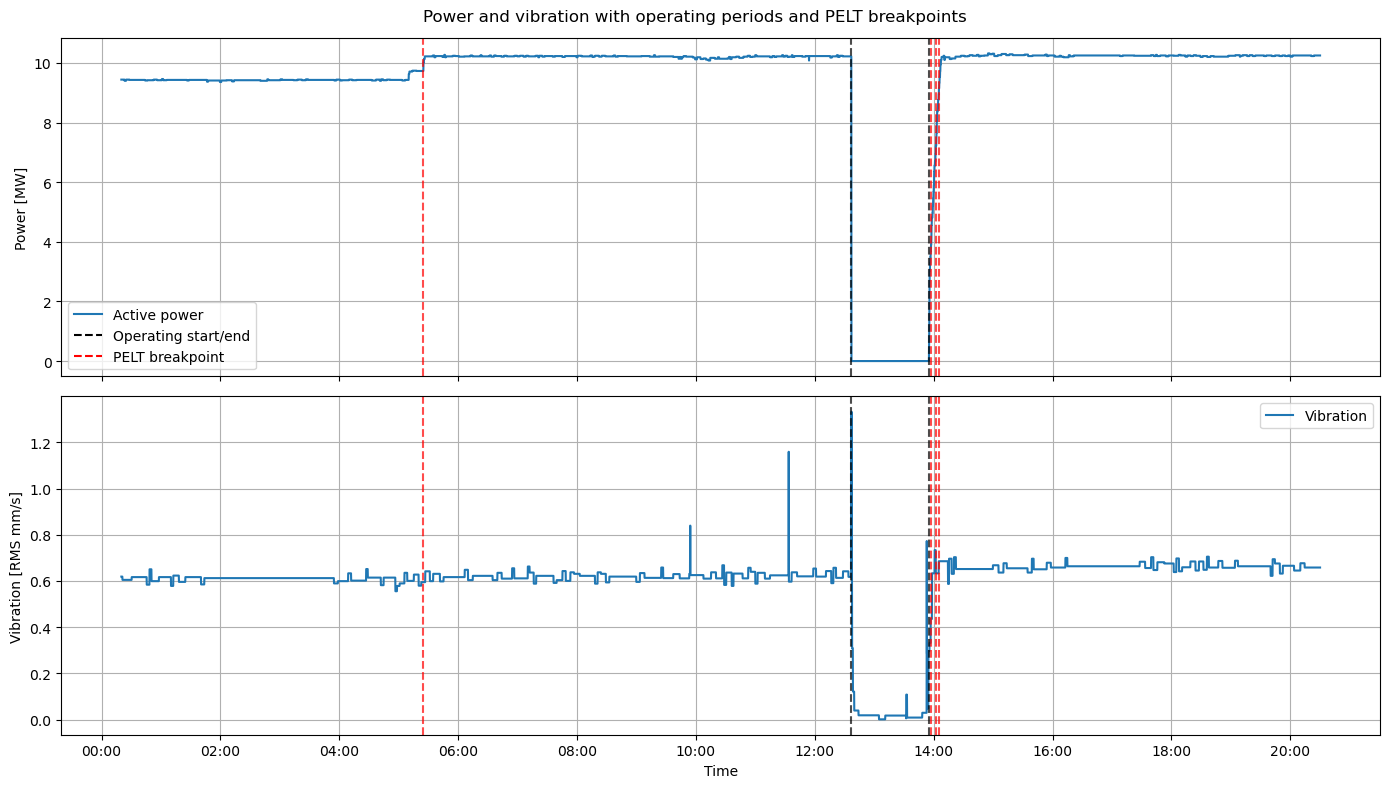

In [7]:
plot_start = pd.Timestamp("2024-06-01 00:20:00")
plot_end = plot_start + pd.Timedelta(hours=20, minutes=10)

power_plot = power[power["Datetime"].between(plot_start, plot_end)]
vib_plot = vib[vib["Datetime"].between(plot_start, plot_end)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(power_plot["Datetime"], power_plot["signal"], label="Active power")
axes[1].plot(vib_plot["Datetime"], vib_plot["signal"], label="Vibration")

axes[0].set_ylabel("Power [MW]")
axes[1].set_ylabel("Vibration [RMS mm/s]")
axes[1].set_xlabel("Time")

# Operating period start/end
for _, period in operating_periods.iterrows():
    for t in [period["start_time"], period["end_time"]]:
        if plot_start <= t <= plot_end:
            axes[0].axvline(t, color="black", linestyle="--", alpha=0.7)
            axes[1].axvline(t, color="black", linestyle="--", alpha=0.7)

# PELT breakpoints
for t in pelt_times:
    if plot_start <= t <= plot_end:
        axes[0].axvline(t, color="red", linestyle="--", alpha=0.7)
        axes[1].axvline(t, color="red", linestyle="--", alpha=0.7)

# Labels for vertical lines
axes[0].plot([], [], color="black", linestyle="--", label="Operating start/end")
axes[0].plot([], [], color="red", linestyle="--", label="PELT breakpoint")

for ax in axes:
    ax.grid(True)
    ax.legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.suptitle("Power and vibration with operating periods and PELT breakpoints")
plt.tight_layout()

plt.savefig("power_vibration_pelt_breakpoints.png", dpi=300, bbox_inches="tight")
plt.show()

Making 1 min windows during the operating periods

In [11]:
windows = make_window_features(
    power_df=power,
    operating_periods=operating_periods,
    window_size=6,
    n_periods=6
)

windows.sort_values(by="std_power").head()

,operating_period,start_time,end_time,mean_power,std_power,start_idx,end_idx
7014,4,2024-06-06 00:12:40,2024-06-06 00:13:30,10.24,0.0,19104,19109
7002,4,2024-06-06 00:00:40,2024-06-06 00:01:30,10.21,0.0,19032,19037
7003,4,2024-06-06 00:01:40,2024-06-06 00:02:30,10.21,0.0,19038,19043
7005,4,2024-06-06 00:03:40,2024-06-06 00:04:30,10.24,0.0,19050,19055
7006,4,2024-06-06 00:04:40,2024-06-06 00:05:30,10.24,0.0,19056,19061


Calculating mean and standard deviatons for windows as features.
Testing with different epsilon values for the DBSCAN to identify the optimal value

In [12]:
eps_results = test_dbscan_eps(
    windows,
    eps_start=0.05,
    eps_stop=0.35,
    eps_step=0.02,
    min_samples=5
)

eps_results

,epsilon,n_clusters,noise_percent
0,0.05,52,3.592446
1,0.07,15,2.134387
2,0.09,5,1.519543
3,0.11,6,1.264822
4,0.13,6,1.141853
5,0.15,6,1.036451
6,0.17,7,0.931050
7,0.19,4,0.887132
8,0.21,4,0.834431
9,0.23,3,0.825648


Extract steady state using the optimal epsilon

In [13]:
windows, steady_intervals = extract_steady_states_from_windows(
    windows,
    eps=0.09,
    min_samples=5
)

Summary table

In [14]:
summary = (
    windows
    .groupby("cluster")
    .agg(
        n_windows=("cluster", "size"),
        mean_power=("mean_power", "mean"),
        mean_std_power=("std_power", "mean"),
        min_power=("mean_power", "min"),
        max_power=("mean_power", "max")
    )
    .sort_index()
)

summary

,n_windows,mean_power,mean_std_power,min_power,max_power
cluster,,,,,
-1,173,6.377206,0.198529,0.536667,10.246667
0,10835,8.802822,0.003990,5.100000,10.410000
1,263,3.951305,0.000769,3.690000,4.060000
2,5,3.977333,0.025646,3.936667,4.001667
3,102,0.878693,0.000787,0.690000,1.080000
4,7,0.755000,0.023411,0.698333,0.800000


Fixing the colours for each cluster and noise

In [15]:
clusters = sorted(windows["cluster"].unique())

base_colors = [
    "tab:orange",
    "tab:green",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan"
]

cluster_colors = {}

for i, cluster in enumerate(clusters):
    if cluster == -1:
        cluster_colors[cluster] = "tab:blue"   # noise color
    else:
        cluster_colors[cluster] = base_colors[i % len(base_colors)]

noise_handle = mpatches.Patch(color="tab:blue", label="Noise")

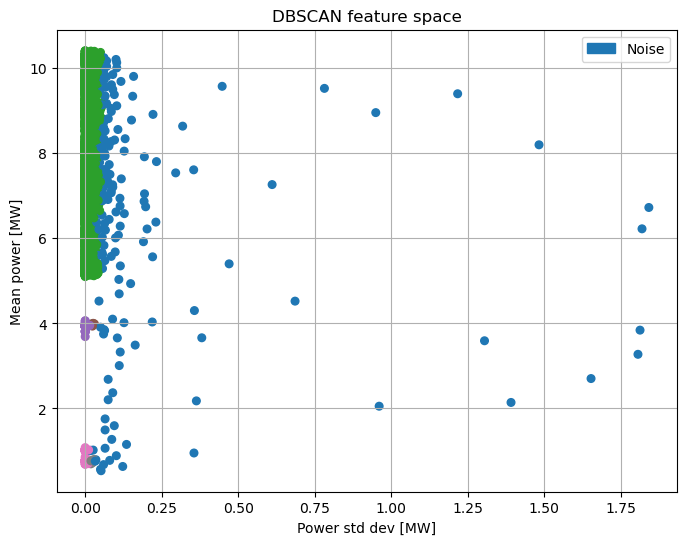

In [16]:
point_colors = windows["cluster"].map(cluster_colors)

plt.figure(figsize=(8, 6))

plt.scatter(
    windows["std_power"],
    windows["mean_power"],
    c=point_colors,
    s=30
)

plt.legend(handles=[noise_handle])

plt.xlabel("Power std dev [MW]")
plt.ylabel("Mean power [MW]")
plt.title("DBSCAN feature space")
plt.grid(True)
plt.show()

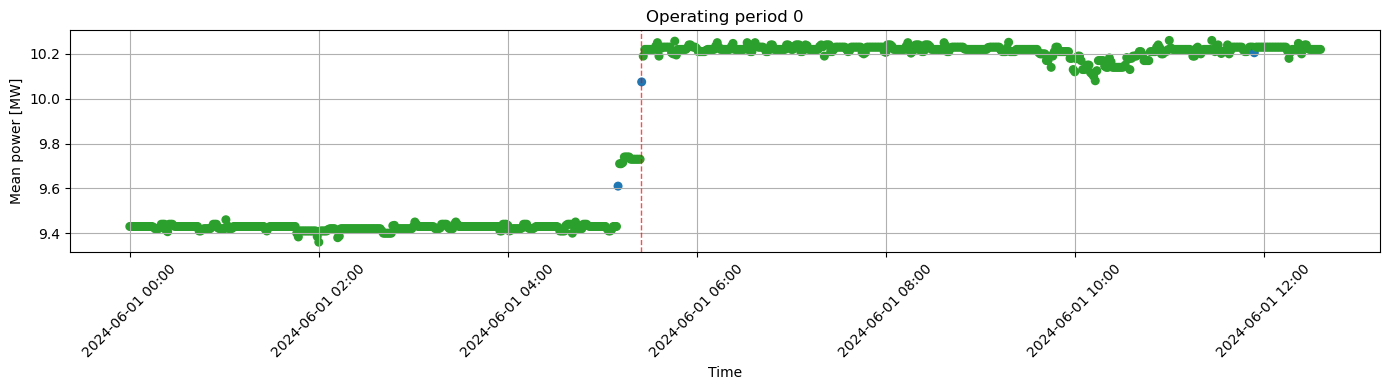

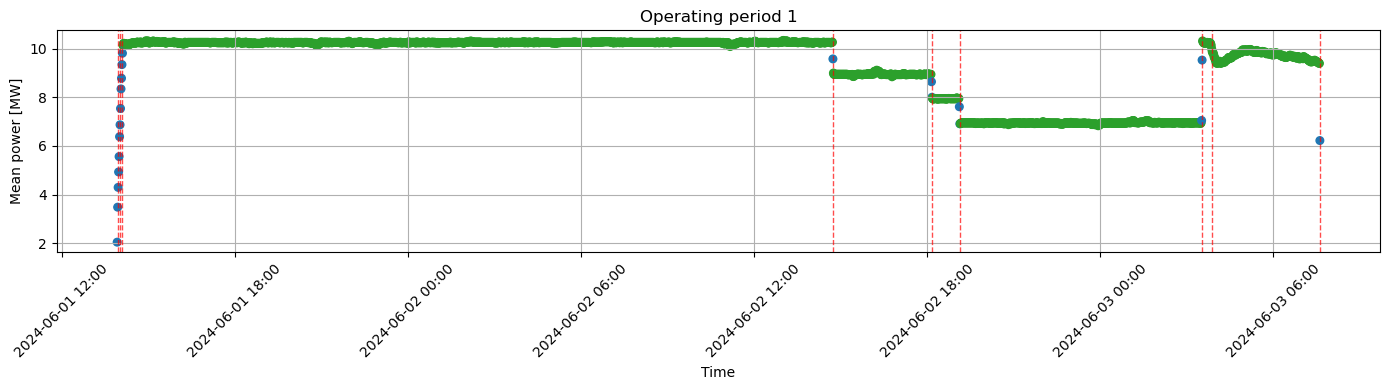

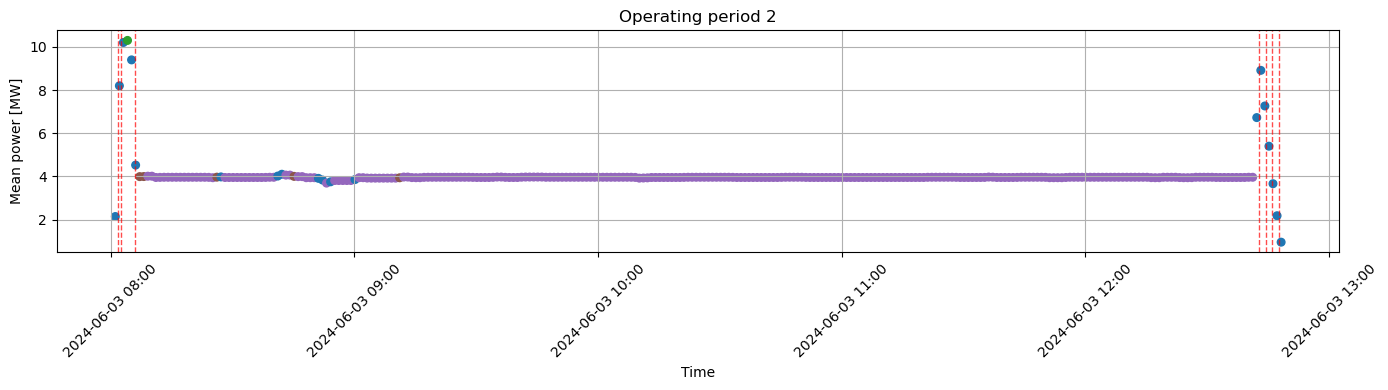

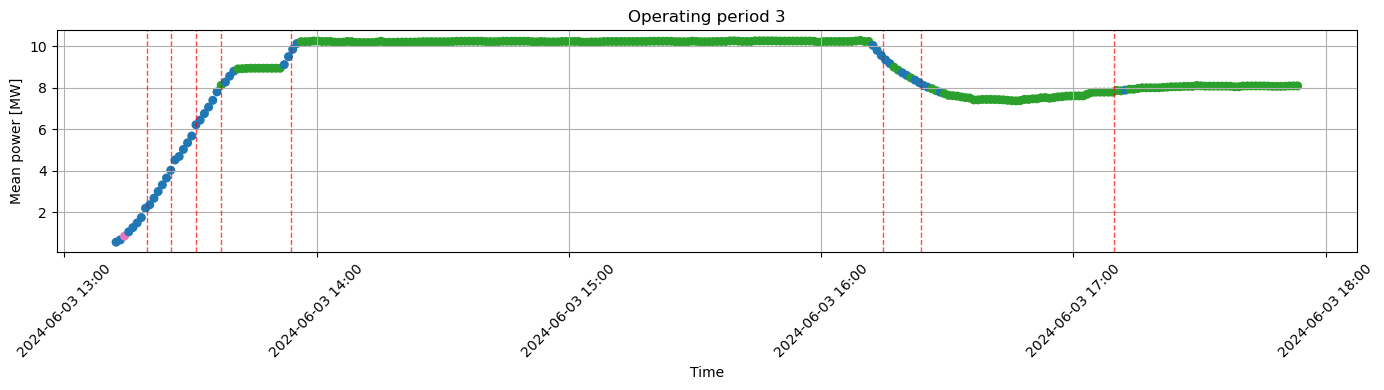

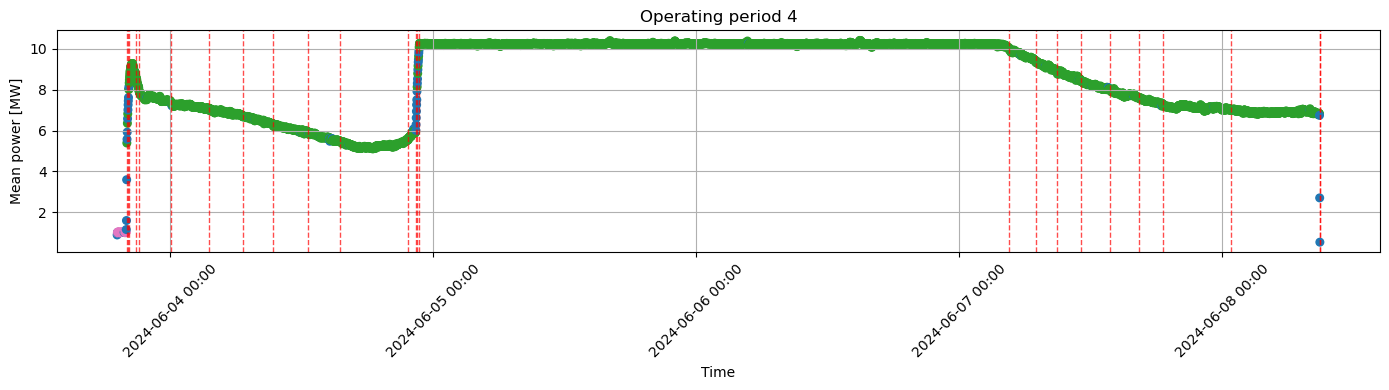

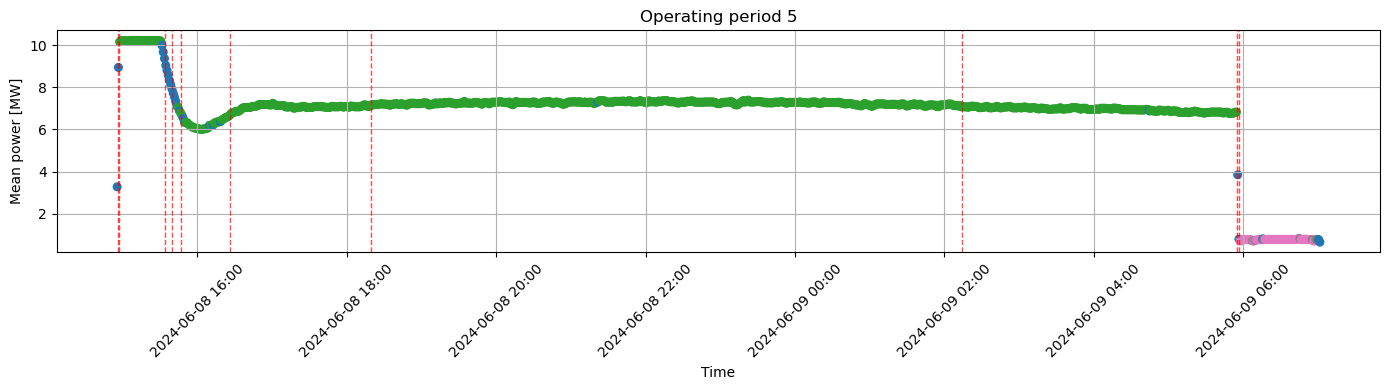

In [17]:
for op in sorted(windows["operating_period"].unique()):
    temp = windows[windows["operating_period"] == op]
    temp_colors = temp["cluster"].map(cluster_colors)

    plt.figure(figsize=(14, 4))

    plt.scatter(
        temp["start_time"],
        temp["mean_power"],
        c=temp_colors,
        s=30
    )

    for t in pelt_times:
        if temp["start_time"].min() <= t <= temp["end_time"].max():
            plt.axvline(t, color="red", linestyle="--", linewidth=1, alpha=0.7)

    plt.xlabel("Time")
    plt.ylabel("Mean power [MW]")
    plt.title(f"Operating period {op}")
    plt.grid(True)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [18]:
corr_df = correlate_with_vibration(
    dfs=dfs,
    power_df=power,
    operating_periods=operating_periods,
    vib_name=vib_name
)

corr_df

,Signal,Pearson,Distance
5,G2 Generator aktiv effekt [MW],0.710977,0.719434
4,Magnetisering feltstrøm,0.617325,0.628380
0,Trykk i turbininnløp Middelverdi (Hydrocord),-0.595557,0.623502
1,Turbin 2 Ledeapparat posisjon,0.475029,0.435836
3,G2 Lagerolje DE temp.,0.226480,0.236057
6,G2 Lagertemp. 2 DE radial,-0.205099,0.219484
2,Turbin 2 Turtall,0.023424,0.031077


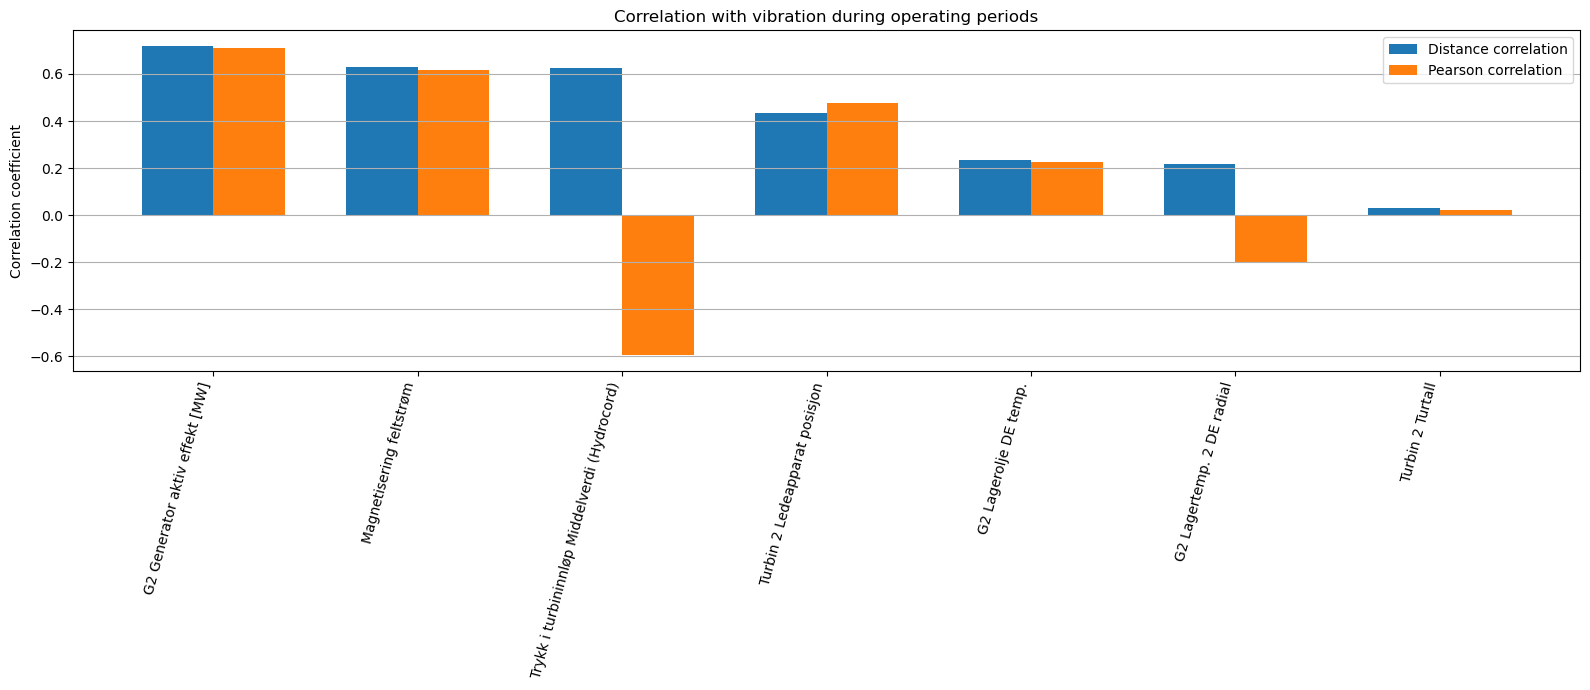

In [65]:
x = np.arange(len(corr_df))
w = 0.35

plt.figure(figsize=(16, 7))

plt.bar(x - w/2, corr_df["Distance"], width=w, label="Distance correlation")
plt.bar(x + w/2, corr_df["Pearson"], width=w, label="Pearson correlation")

plt.xticks(x, corr_df["Signal"], rotation=75, ha="right")
plt.ylabel("Correlation coefficient")
plt.title("Correlation with vibration during operating periods")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()

plt.savefig("correlation_with_vibration_operating_periods.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
vib_signal = vib.rename(columns={"signal": "vibration"}).copy()

vibration_means = []

for _, row in windows.iterrows():
    temp = vib_signal[
        vib_signal["Datetime"].between(row["start_time"], row["end_time"])
    ]

    vibration_means.append(temp["vibration"].mean())

windows["vibration_mean"] = vibration_means

model_windows = windows.dropna(subset=["vibration_mean"]).copy()

print("Windows:", len(windows))
print("Model windows:", len(model_windows))
print("Start:", model_windows["start_time"].min())
print("End:", model_windows["start_time"].max())

Windows: 11385
Model windows: 11385
Start: 2024-06-01 00:00:00
End: 2024-06-09 07:01:30


In [86]:
model_windows = windows.dropna(subset=["vibration_mean"]).copy()

In [87]:
feature_cols = [
    "mean_power",
    "std_power",
    "cluster"
]

target_col = "vibration_mean"

X = model_windows[feature_cols]
y = model_windows[target_col]

In [88]:
split = int(len(model_windows) * 0.7)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

X_test = X.iloc[split:]
y_test = y.iloc[split:]

test_time = model_windows["start_time"].iloc[split:]

In [89]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 0.017642301465721832
RMSE: 0.0212896469597278


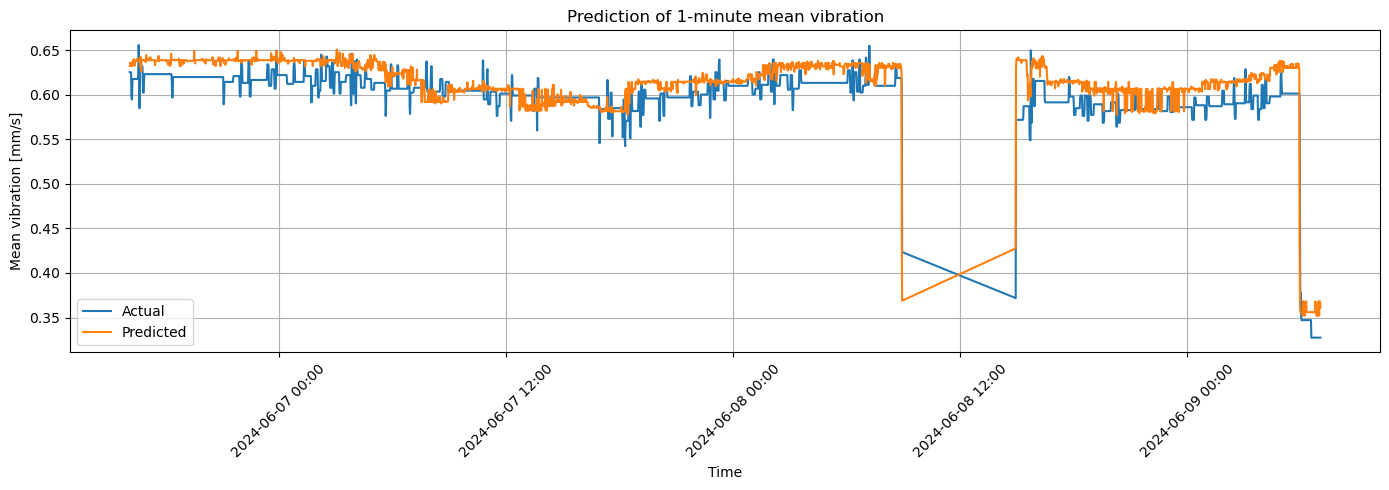

In [90]:
plt.figure(figsize=(14, 5))

plt.plot(test_time, y_test, label="Actual")
plt.plot(test_time, y_pred, label="Predicted")

plt.xlabel("Time")
plt.ylabel("Mean vibration [mm/s]")
plt.title("Prediction of 1-minute mean vibration")
plt.legend()
plt.grid(True)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [84]:
print("Test start:", test_time.min())
print("Test end:", test_time.max())
print("Duration:", test_time.max() - test_time.min())

Test start: 2024-06-01 08:49:00
Test end: 2024-06-01 12:36:00
Duration: 0 days 03:47:00


In [70]:
signals = {
    "power": power,
    "guide_vane_pos": pos,
    "inlet_pressure": inletp,
    "field_current": field_current,
    "speed": speed,
    "vibration": vib
}

model_df = None

for name, df in signals.items():
    temp = df[["Datetime", "signal"]].rename(columns={"signal": name})

    if model_df is None:
        model_df = temp
    else:
        model_df = model_df.merge(temp, on="Datetime")

model_df = model_df.dropna().sort_values("Datetime").reset_index(drop=True)

model_df.head()

,Datetime,power,guide_vane_pos,inlet_pressure,field_current,speed,vibration
0,2024-06-01 00:00:00,9.429999,75.339462,3826.189043,6.925309,100.152733,0.586103
1,2024-06-01 00:00:10,9.429999,75.339462,3826.189043,6.942870,100.094093,0.586103
2,2024-06-01 00:00:20,9.429999,75.339462,3826.189043,6.953251,100.064537,0.586103
3,2024-06-01 00:00:30,9.429999,75.339462,3826.189043,6.942584,100.064537,0.586103
4,2024-06-01 00:00:40,9.429999,75.339462,3826.189043,6.968599,99.977997,0.586103


In [71]:
model_df = model_df[
    (model_df["speed"] >= 90) &
    (model_df["power"] >= 0.5)
].copy()

model_df = model_df.reset_index(drop=True)

In [31]:
feature_cols = [
    "power",
    "guide_vane_pos",
    "inlet_pressure",
    "field_current"
]

target_col = "vibration"

X = model_df[feature_cols]
y = model_df[target_col]

In [33]:
split = int(len(model_df) * 0.7)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

X_test = X.iloc[split:]
y_test = y.iloc[split:]

test_time = model_df["Datetime"].iloc[split:]

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 0.04311863853745054
RMSE: 0.059922145979083886


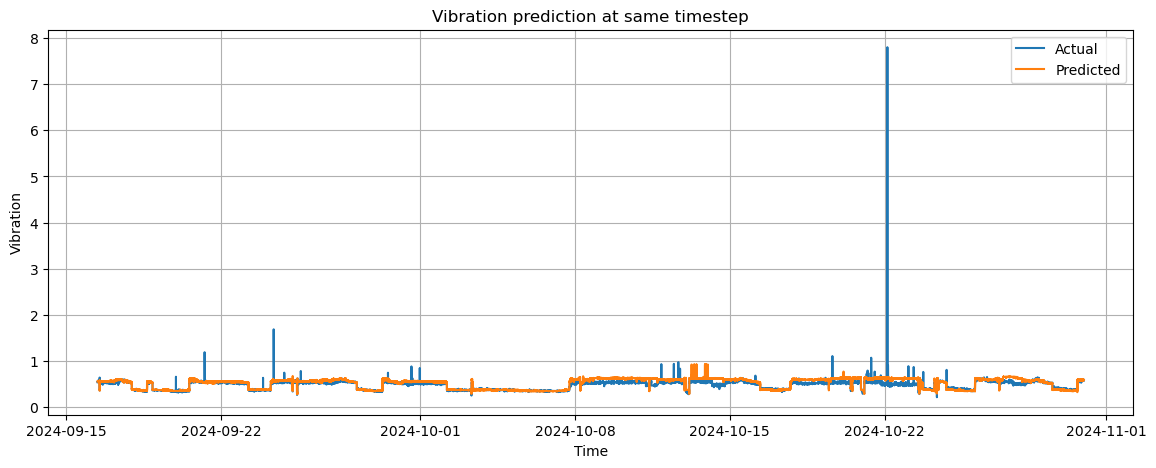

In [43]:
plt.figure(figsize=(14, 5))

plt.plot(test_time, y_test, label="Actual")
plt.plot(test_time, y_pred, label="Predicted")

plt.xlabel("Time")
plt.ylabel("Vibration")
plt.title("Vibration prediction at same timestep")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
baseline_pred = np.full_like(y_test, y_train.mean())

print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))

Baseline MAE: 0.06609196523670265
Baseline RMSE: 0.09138913488023463


In [44]:
op = operating_periods.sort_values("start_time").reset_index(drop=True)

off_periods = pd.DataFrame({
    "start_time": op["end_time"].shift(1),
    "end_time": op["start_time"]
}).dropna()

off_periods["duration"] = off_periods["end_time"] - off_periods["start_time"]
off_periods["duration_hours"] = off_periods["duration"].dt.total_seconds() / 3600

off_periods = off_periods.sort_values("duration", ascending=False).reset_index(drop=True)

print("Number of off periods:", len(off_periods))
print("Longest off period:")
print("Start:", off_periods.loc[0, "start_time"])
print("End:", off_periods.loc[0, "end_time"])
print("Duration:", off_periods.loc[0, "duration"])
print("Duration hours:", round(off_periods.loc[0, "duration_hours"], 2))

off_periods.head(10)

Number of off periods: 58
Longest off period:
Start: 2024-08-24 23:04:30
End: 2024-08-25 06:38:50
Duration: 0 days 07:34:20
Duration hours: 7.57


,start_time,end_time,duration,duration_hours
0,2024-08-24 23:04:30,2024-08-25 06:38:50,0 days 07:34:20,7.572222
1,2024-08-25 06:44:20,2024-08-25 13:51:30,0 days 07:07:10,7.119444
2,2024-06-25 06:22:50,2024-06-25 13:16:10,0 days 06:53:20,6.888889
3,2024-07-14 08:02:10,2024-07-14 14:08:50,0 days 06:06:40,6.111111
4,2024-06-08 08:57:00,2024-06-08 14:55:30,0 days 05:58:30,5.975000
5,2024-08-11 08:06:40,2024-08-11 14:00:30,0 days 05:53:50,5.897222
6,2024-06-09 07:02:20,2024-06-09 12:38:50,0 days 05:36:30,5.608333
7,2024-08-10 10:31:50,2024-08-10 14:52:40,0 days 04:20:50,4.347222
8,2024-06-26 06:26:00,2024-06-26 10:41:50,0 days 04:15:50,4.263889
9,2024-07-07 09:07:10,2024-07-07 13:07:10,0 days 04:00:00,4.000000


In [49]:
vib_signal = vib.rename(columns={"signal": "vibration"})

vibration_means = []

for _, row in windows.iterrows():
    temp = vib_signal[
        vib_signal["Datetime"].between(row["start_time"], row["end_time"])
    ]

    vibration_means.append(temp["vibration"].mean())

windows["vibration_mean"] = vibration_means

NameError: name 'windows' is not defined